In [1]:
!pip install scikit-learn matplotlib seaborn -q

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_FOLDER="/content/drive/MyDrive/CBR-PHI"

RESULT_PATH=os.path.join(
    PROJECT_FOLDER,
    "data",
    "results",
    "prediction_results.csv"
)

df=pd.read_csv(RESULT_PATH)

df.head()

,Actual,Prediction
0,Ditolak,Ditolak
1,Ditolak,Ditolak
2,Ditolak,Ditolak
3,Ditolak,Ditolak
4,Dikabulkan,Ditolak


In [4]:
y_true=df["Actual"]

y_pred=df["Prediction"]

In [5]:
accuracy=accuracy_score(
    y_true,
    y_pred
)

print("Accuracy :",round(accuracy,4))

Accuracy : 0.7333


In [6]:
precision=precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Precision :",round(precision,4))

Precision : 0.5378


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
recall=recall_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Recall :",round(recall,4))

Recall : 0.7333


In [8]:
f1=f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("F1 Score :",round(f1,4))

F1 Score : 0.6205


In [9]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

  Dikabulkan       0.00      0.00      0.00         4
     Ditolak       0.73      1.00      0.85        22
     Lainnya       0.00      0.00      0.00         4

    accuracy                           0.73        30
   macro avg       0.24      0.33      0.28        30
weighted avg       0.54      0.73      0.62        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


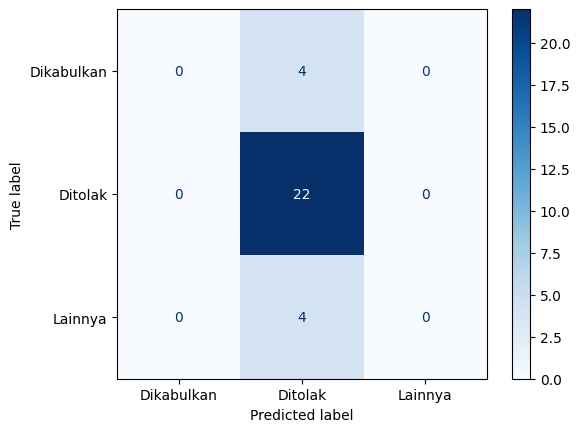

In [10]:
cm=confusion_matrix(
    y_true,
    y_pred
)

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(df["Actual"].unique())
)

disp.plot(cmap="Blues")

plt.show()

In [11]:
evaluation=pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

evaluation

,Metric,Value
0,Accuracy,0.733333
1,Precision,0.537778
2,Recall,0.733333
3,F1 Score,0.620513


In [12]:
output=os.path.join(
    PROJECT_FOLDER,
    "data",
    "eval",
    "evaluation.csv"
)

evaluation.to_csv(
    output,
    index=False
)

print(output)

/content/drive/MyDrive/CBR-PHI/data/eval/evaluation.csv
